# Machine Forgetters CS5841 Final Project Code File
Connor Donahue, Connor Fleser, Jessica Feliz Garrido, and Matthew Harrelson

## **Imports**: import packages used in the notebook

In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
import gc
from sklearn.model_selection import KFold
import seaborn as sns
import ast

2026-03-23 08:07:02.222933: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-23 08:07:02.223027: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-23 08:07:02.225208: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-23 08:07:02.238391: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-23 08:07:03.177631: W tensorflow/compiler/tf2

## **Load Data**: load data used to construct model
- Our MALDI-TOF data was taken from two seperate CSV files and combined into one dataset. One CSV file contained only pure spectra, and the other contained mixed and pure spectra. The pure spectra from the latter CSV fas filtered out and added to the other pure spectra for a total of 651 samples. 

In [2]:
# read in feature data from two csv files
df1 = pd.read_csv("data/pure_spectra_matrix.csv", sep=";", header = None, decimal =".")
df2 = pd.read_csv("data/mixed_spectra_matrix.csv", sep=";", header = None, decimal =".")

# read in label data from label files
labels1 = pd.read_csv("data/pure_spectra_metadata.csv", sep=";")["Species"]

# for second pair of feature and label file, pure spectra must be separated from mixed spectra 
temp_labels2 =  pd.read_csv("data/mixed_spectra_metadata.csv", sep=";")
labels2 = temp_labels2[(temp_labels2['Proportion'] == 0) | (temp_labels2['Proportion'] == 1)]  
df2 = df2[(temp_labels2['Proportion'] == 0) | (temp_labels2['Proportion'] == 1)]

# store labels for pure spectra
species = []
for i in range(labels2.shape[0]):
    if (labels2['Proportion'].iloc[i] == 0):
        species.append(labels2["Species_2"].iloc[i])
    else: 
        species.append(labels2["Species_1"].iloc[i])

labels2 = pd.Series(species)

# combine two data sets into one dataframe
df = pd.concat([df1, df2])
labels = pd.concat([labels1, labels2])

# visualize first few entries in the dataframe
df.head()

,0,1,2,3,4,5,6,7,8,9,...,1290,1291,1292,1293,1294,1295,1296,1297,1298,1299
0,0,0.0,0.0,0.0,0.0,0,44431.921875,0.0,0.0,0.0,...,0.000000,0.0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0.0,...,27667.777344,0.0,0,0.0,35438.351562,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0.0,...,59820.968750,0.0,0,0.0,6384.590820,0.0,0.0,0.0,0.0,0.0
3,0,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0.0,0.0,0.0,0,4701.712402,0.0,0.0,0.0,...,3913.969727,0.0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


## **Preprocessing and Splitting Data**

### Global Variables and Random Seeds

In [3]:
# set fixed batch size, number of epochs, and random seed
BATCH = 32
EPOCHS = 50
SEED = 1
HE = tf.keras.initializers.HeNormal(seed=SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Training and Testing Spit
- A 10%/90% test/training + validation split, stratified on the outcome classes, was conducted and outcome labels were encoded with integers.

In [4]:
# training and testing split (10% test, 10% validation, 80% training)
X_trainval, X_test, y_trainval, y_test = train_test_split(df, labels, test_size = 0.1, stratify=labels)

# encode categorical labels  
le = LabelEncoder()
y_trainval = le.fit_transform(y_trainval)
y_test = le.transform(y_test)

# identify number of outcome classes
num_classes = len(labels.unique())

# display dimensions of training + validation and test data
print(X_trainval.shape)
print(X_test.shape)

(585, 1300)
(66, 1300)


### Preprocessing and Batching
- To preprocess the data, a log transformation is applied so that the model does overfit large peaks and effectively ignore small peaks, which can still be informative.
- Next, a series of functions for accessing the preprocessed training + validation set and the testing set was created. Each function preprocesses and batches the samples.
- Finally, plots are displayed to visualize what the original and preprocessed data samples look like.

(32, 1300, 1) (32,)
range: tf.Tensor(0.0, shape=(), dtype=float64) - tf.Tensor(17.547974674913657, shape=(), dtype=float64)


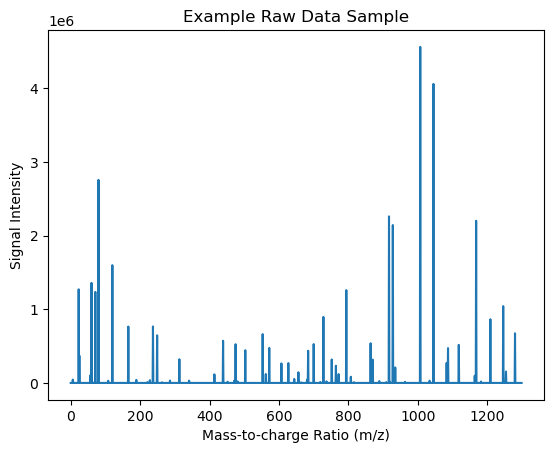

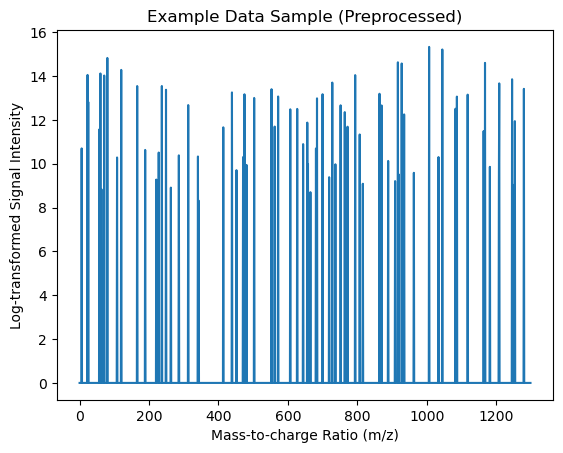

In [5]:
# define helper functions for preprocessing and accessing data
def preprocess(x, y):
  x = tf.math.log1p(x)
  x = tf.expand_dims(x, axis=-1)
  return x, y

def getTrainValData():
  return tf.data.Dataset.from_tensor_slices((X_trainval, y_trainval)).map(preprocess,tf.data.AUTOTUNE).shuffle(buffer_size=64).batch(BATCH).prefetch(tf.data.AUTOTUNE)

def getTestData():
  return tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(preprocess,tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

# output structure of each training batch
img, label = next(iter(getTrainValData()))
print(img.shape, label.shape)
print("range: " + str(tf.reduce_min(img)) + " - " + str(tf.reduce_max(img)))

# plot visualization of original training sample
plt.plot(df.iloc[0])
plt.title("Example Raw Data Sample")
plt.ylabel('Signal Intensity')
plt.xlabel('Mass-to-charge Ratio (m/z)')
plt.savefig('figures/original_data.png')
plt.show()

# plot visualization of preprocessed sample
plt.plot(preprocess(df.iloc[0], 0)[0])
plt.title("Example Data Sample (Preprocessed)")
plt.ylabel('Log-transformed Signal Intensity')
plt.xlabel('Mass-to-charge Ratio (m/z)')
plt.savefig('figures/preprocessed_data.png')
plt.show()

## Set up Model Compliation and Fitting
- Helper functions were created to compile and fit each model with the following specifications:
    - Adam optimization with 0.001 initial learning rate.
    - Sparse categorical cross-entropy loss function.
    - Callback to restore parameters resulting in optimal validation loss after 20 epochs of no improvement.
        - The "compile_fit_model()" function returns the average validation accuracy of the model across 5 cross-validation folds.  

In [6]:
# function for creating training callback to paramters with optimal validation loss after early stoppping 
def create_callbacks():
    callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,         
        verbose=1,          
        restore_best_weights=True 
    )

    return callback

# function for compiling and fitting model using Adam optimizer and sparse categorical cross-entropy loss
def compile_fit_model(m = None, l = None, a = None, h = None, d = None):
    fold_no = 1
    k = 5
    kfold = KFold(n_splits=k, shuffle=True, random_state=SEED) 
    scores = []

    # train the model once on each fold
    for train_index, val_index in kfold.split(X_trainval, y_trainval):
    
        # Split data into training and test sets for the current fold
        X_train_fold = X_trainval.iloc[train_index]
        y_train_fold = y_trainval[train_index]
        X_val_fold = X_trainval.iloc[val_index]
        y_val_fold = y_trainval[val_index]

        # preprocess and batch the separated training and validation folds 
        train_fold = tf.data.Dataset.from_tensor_slices((X_train_fold, y_train_fold)).map(preprocess,tf.data.AUTOTUNE).shuffle(buffer_size=64).batch(BATCH).prefetch(tf.data.AUTOTUNE)
        val_fold = tf.data.Dataset.from_tensor_slices((X_val_fold, y_val_fold)).map(preprocess,tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

        # a new model is created for each fold in order to avoid leakage
        if m == "ffn":
            model = build_ffn(l, a)
        elif m == "cnn":
            model = build_cnn(l, a)
        else:
            model = build_att(h, d, a)
        
        # Create and compile the model
        model.compile(
            optimizer=tf.keras.optimizers.Adam(1e-3),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"]
        )
    
        # Train the model
        hist = model.fit(
            train_fold,
            validation_data = val_fold,
            epochs = EPOCHS,
            callbacks = create_callbacks(),
            verbose = 0
        )
    
        # Evaluate the model
        scores.append(max(hist.history["val_accuracy"]))

        # clear previous training
        tf.keras.backend.clear_session()

        # delete the model
        del model
        
        fold_no += 1
     
    # return the mean validation accuracy for the model
    return np.mean(scores)
    

## Model Construction
- A function was created to construct each type of model with different parameter values to specify architecture and activation functions. Refer to code comments for details of each model-building function.

### Model 1: Feed-Forward Neural Network

In [7]:
# function for building feed-forward neural network with dropout and adjustable activation function and layer architecture
def build_ffn(layers_arch, act_func):
    # input layer with batch normalization
    inputs = layers.Input(shape=(X_trainval.shape[1],))
    x = layers.BatchNormalization()(inputs)
            
    # create layer architecture (depth and width) specified in arguments
    for layer_size in layers_arch:
        x = layers.Dense(layer_size, activation=act_func, kernel_initializer=HE)(x)
        x = layers.Dropout(0.2)(x)
        x = layers.BatchNormalization()(x)
    
    # softmax output layer
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    # Create model
    ffn = tf.keras.Model(inputs=inputs, outputs=outputs, name="FeedForwardNeuralNetwork")

    # return model object
    return ffn

### Model 2: 1-Dimensional Convolutional Neural Network

In [8]:
# function for building convolutional neural network with variable layer architecture and activation function
def build_cnn(layers_arch, act_func):
    # input layer with batch normalization
    inputs = layers.Input(shape=(X_trainval.shape[1],))   
    x = layers.BatchNormalization()(inputs)

    # expand input to 3 dimensions for convolution layer
    x = tf.expand_dims(x, axis=-1)

    # create layer architecture (# filters and kernel dimension) specified in arguments
    for layer in layers_arch:
        tmpx = x
        x = layers.Conv1D(layer[0], layer[1], activation=act_func, padding="same")(x)
        if tmpx.shape[-1] != layer[0]:
            tmpx = layers.Conv1D(layer[0], 1, padding="same")(tmpx)
        x = layers.Add()([x, tmpx])
        x = layers.MaxPooling1D(2)(x)
    
    # Flatten and Classify with feed-forward layer and softmax
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    # store model
    cnn = tf.keras.Model(inputs, outputs, name = 'ConvolutionalNeuralNetwork')

    # return model object
    return cnn


### Model 3: Attention-Based Model

In [9]:
# function for building attention-based model with variable number of heads and key dimension
def build_att(num_heads=2, dim = 2, act_func="relu"):
    # input layer with batch normalization
    inputs = layers.Input(shape=(X_trainval.shape[1],))   
    x = layers.BatchNormalization()(inputs)
    
    # expand input to 3 dimensions for attention layer
    x = tf.expand_dims(inputs, axis=1)
    
    # store inputs for residual connection
    shortcut = x
    
    # attention layer with specified number of heads and key dimension
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)(x, x)
    
    # residual connection and batch normalization 
    x = layers.Add()([x, shortcut])
    x = layers.BatchNormalization()(x)
    
    # dense layer with leaky relu activation, dropout, and batch normalization
    x = layers.Dense(256, activation=act_func, kernel_initializer=HE)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    
    # flatten data back to 2 dimensions and apply softmax activation layer
    x = layers.Flatten()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    # store model
    att = tf.keras.Model(inputs, outputs, name = 'AttentionBasedNeuralNetwork')

    # return model object
    return att

## Setting up model comparative tests
- Each model was constructed and validated across a range of different architectures. The performance results of each set of parameters was added to a DataFrame for camparison purposes and plotted for visualzation.

In [10]:
# construct ffns with different layer architectures
ffn_layers = [[1024,128], [1024, 256], [256, 256], [1024, 256, 128]]

# construct ffns using relu and leaky relu activation
ffn_act_funcs = ["relu", layers.LeakyReLU(alpha=0.2)]

ffn_tests = []

# compile, train, and store model for each combination of architecture and activation function
for act_func in ffn_act_funcs:
    for layer_arch in ffn_layers:
        ffn_tests.append({
            "act_func": act_func,
            "layers": str(layer_arch),
            "val_accuracy": compile_fit_model('ffn', layer_arch, act_func)
        })
        gc.collect()

# store results in a dataframe for later reference
ffn_df = pd.DataFrame(ffn_tests)

ffn_df

Restoring model weights from the end of the best epoch: 12.
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 19.
Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 14.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 23.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 16.
Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 13.
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 10.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 7.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 18.
Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 11.
Epoch 31

,act_func,layers,val_accuracy
0,relu,"[1024, 128]",0.938462
1,relu,"[1024, 256]",0.929915
2,relu,"[256, 256]",0.929915
3,relu,"[1024, 256, 128]",0.935043
4,<keras.src.layers.activation.leaky_relu.LeakyR...,"[1024, 128]",0.933333
5,<keras.src.layers.activation.leaky_relu.LeakyR...,"[1024, 256]",0.941880
6,<keras.src.layers.activation.leaky_relu.LeakyR...,"[256, 256]",0.940171
7,<keras.src.layers.activation.leaky_relu.LeakyR...,"[1024, 256, 128]",0.943590


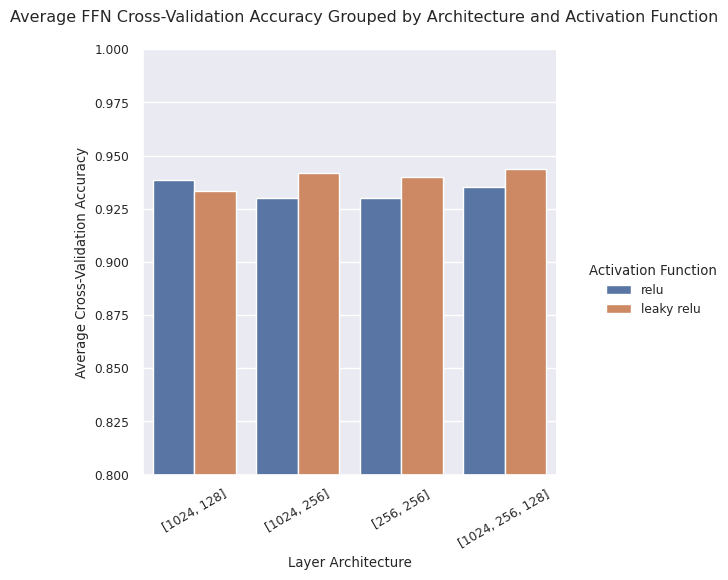

In [11]:
# create copy of results df and change activation function to more understandable value
ffn_df_p = ffn_df.copy(deep=True)
ffn_df_p.loc[ffn_df_p['act_func'] != 'relu', 'act_func'] = 'leaky relu'

# plot FFN cross-validation results
sns.set_theme(font_scale=0.8)
p = sns.catplot(
    x="layers",      
    y="val_accuracy",       
    hue="act_func", 
    data=ffn_df_p,     
    kind="bar",
)

# plot customization
p.set(ylim=(0.8, 1)) 
p.set_axis_labels("Layer Architecture", "Average Cross-Validation Accuracy")
p.fig.suptitle("Average FFN Cross-Validation Accuracy Grouped by Architecture and Activation Function", y=1.05) 
p.legend.set_title("Activation Function")
p.set_xticklabels(rotation=30, horizontalalignment='center')

p.savefig('figures/ffn_results.png', bbox_inches='tight')
plt.show()

In [12]:
# construct cnns with different layer architectures
cnn_layers = [
    [[32,32], [32, 64]], 
    [[32,16], [32, 64]],
    [[32,32], [64, 32]],
    [[32,16], [64, 32]]    
]

# construct cnns using relu and leaky relu activation
cnn_act_funcs = ["relu", layers.LeakyReLU(alpha=0.2)]

cnn_tests = []

# compile, train, and store model for each combination of architecture and activation function
for act_func in cnn_act_funcs:
    for layer_arch in cnn_layers:
        cnn_tests.append({
            "act_func": act_func,
            "layers": str(layer_arch),
            "val_accuracy": compile_fit_model('cnn', layer_arch, act_func)
        })
        gc.collect()

# store results in a dataframe for later reference
cnn_df = pd.DataFrame(cnn_tests)

cnn_df

Restoring model weights from the end of the best epoch: 12.
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 13.
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 5.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 17.
Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 6.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 14.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 5.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 7.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 6.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 12.
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 8.
Epoch 28: ea

,act_func,layers,val_accuracy
0,relu,"[[32, 32], [32, 64]]",0.909402
1,relu,"[[32, 16], [32, 64]]",0.900855
2,relu,"[[32, 32], [64, 32]]",0.911111
3,relu,"[[32, 16], [64, 32]]",0.924786
4,<keras.src.layers.activation.leaky_relu.LeakyR...,"[[32, 32], [32, 64]]",0.911111
5,<keras.src.layers.activation.leaky_relu.LeakyR...,"[[32, 16], [32, 64]]",0.912821
6,<keras.src.layers.activation.leaky_relu.LeakyR...,"[[32, 32], [64, 32]]",0.923077
7,<keras.src.layers.activation.leaky_relu.LeakyR...,"[[32, 16], [64, 32]]",0.914530


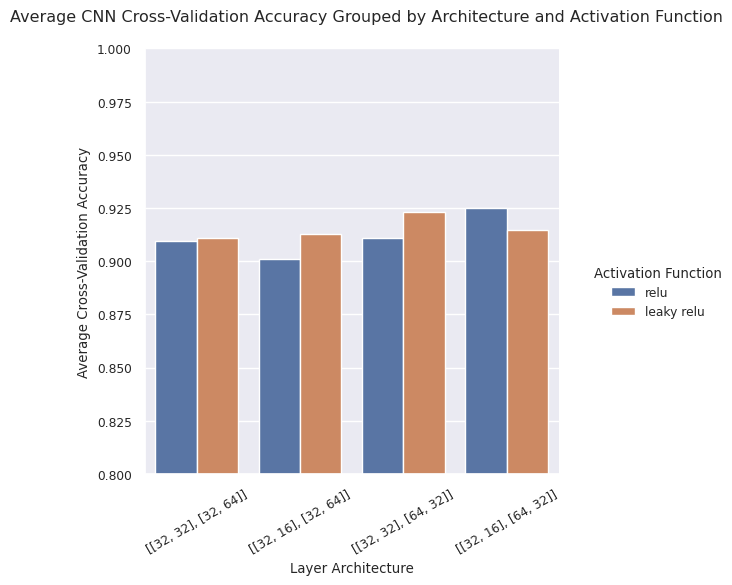

In [13]:
# create copy of results dataframe and change activation function to more understandable value
cnn_df_p = cnn_df.copy(deep=True)
cnn_df_p.loc[cnn_df_p['act_func'] != 'relu', 'act_func'] = 'leaky relu'

# plot CNN cross-validation results
sns.set_theme(font_scale=0.8)
p = sns.catplot(
    x="layers",       
    y="val_accuracy",   
    hue="act_func",  
    data=cnn_df_p,     
    kind="bar",
)

# plot customization
p.set(ylim=(0.8, 1)) 
p.set_axis_labels("Layer Architecture", "Average Cross-Validation Accuracy")
p.fig.suptitle("Average CNN Cross-Validation Accuracy Grouped by Architecture and Activation Function", y=1.05) 
p.legend.set_title("Activation Function")
p.set_xticklabels(rotation=30, horizontalalignment='center')

p.savefig('figures/cnn_results.png', bbox_inches='tight')
plt.show()

In [14]:
# construct attention models with different key dimensions
att_dims = [4,8,16]

# construct attention models with different numbers of heads
att_num_heads = [4, 8, 16]

# construct atttention models with relu and leaky relu activation
att_act_funcs = ["relu", layers.LeakyReLU(alpha=0.2)]

att_tests = []

# compile, train, and store model for each combination of key dimension, number of heads, and activation function
for num_head in att_num_heads:
    for act_func in att_act_funcs:
        for dim in att_dims:
            att_tests.append({
                    "act_func": act_func,
                    "arch": str([num_head, dim]),
                    "val_accuracy": compile_fit_model('att', a = act_func, h = num_head, d = dim)
                })
            gc.collect()

# store results in a dataframe for later reference
att_df = pd.DataFrame(att_tests)

att_df

Restoring model weights from the end of the best epoch: 20.
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 5.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 23.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 5.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 14.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 6.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 24.
Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 21.
Epoch 41: early stopping
Restoring model weights from the end of the best epoch: 4.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 18.
Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 22.
Epoch 42: 

,act_func,arch,val_accuracy
0,relu,"[4, 4]",0.935043
1,relu,"[4, 8]",0.947009
2,relu,"[4, 16]",0.941880
3,<keras.src.layers.activation.leaky_relu.LeakyR...,"[4, 4]",0.941880
4,<keras.src.layers.activation.leaky_relu.LeakyR...,"[4, 8]",0.943590
5,<keras.src.layers.activation.leaky_relu.LeakyR...,"[4, 16]",0.941880
6,relu,"[8, 4]",0.923077
7,relu,"[8, 8]",0.948718
8,relu,"[8, 16]",0.940171
9,<keras.src.layers.activation.leaky_relu.LeakyR...,"[8, 4]",0.941880


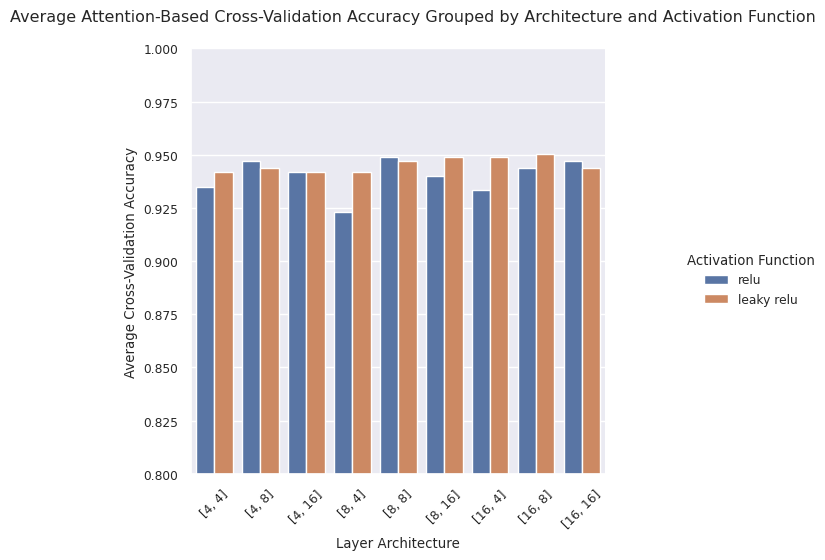

In [15]:
# create copy of results df and change activation function to more understandable value
att_df_p = att_df.copy(deep=True)
att_df_p.loc[att_df_p['act_func'] != 'relu', 'act_func'] = 'leaky relu'

# plot attention-based cross-validation results
sns.set_theme(font_scale=0.8)
p = sns.catplot(
    x="arch",       
    y="val_accuracy",   
    hue="act_func",  
    data=att_df_p,     
    kind="bar",
)

# plot customization
p.set(ylim=(0.8, 1)) 
p.set_axis_labels("Layer Architecture", "Average Cross-Validation Accuracy")
p.fig.suptitle("Average Attention-Based Cross-Validation Accuracy Grouped by Architecture and Activation Function", y=1.05) 
p.legend.set_title("Activation Function")
p.set_xticklabels(rotation=45, horizontalalignment='center')

p.savefig('figures/att_results.png', bbox_inches='tight')
plt.show()

## Model Evaluation
- The training functions were reworked to train the final model on the combined training and validation data, then the model with the highest validation accuracy was identified, trained on the combined data, and evaluated on the test data. 

In [16]:
# function for creating callback to paramters with optimal training loss after early stopping
def create_callbacks_test():
    callback = tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=20,         
        verbose=1,          
        restore_best_weights=True 
    )

# function for compiling and fitting optimal model on training + validation data
def compile_fit_model_test(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    
    hist = model.fit(
        getTrainValData(),
        epochs = EPOCHS,
        callbacks = create_callbacks_test(),
        verbose = 0
    )

    return model.evaluate(getTestData()) 



In [17]:
# identify best model parameters from each type of model
best_ffn = ffn_df.sort_values(by = "val_accuracy", ascending = False).iloc[0]
best_cnn = cnn_df.sort_values(by = "val_accuracy", ascending = False).iloc[0]
best_att = att_df.sort_values(by = "val_accuracy", ascending = False).iloc[0]

# create new models with the same parameters as the best models
ffn = build_ffn(ast.literal_eval(best_ffn['layers']), best_ffn['act_func'])
cnn = build_cnn(ast.literal_eval(best_cnn['layers']), best_cnn['act_func'])
att = build_att(ast.literal_eval(best_att['arch'])[0], ast.literal_eval(best_att['arch'])[0], best_att['act_func'])

# store new models and validation performance metrics in a dataframe
best_models_df = pd.DataFrame({'model': [ffn, cnn, att],
                               'model_name': [ffn.name, cnn.name, att.name],
                               'val_accuracy': [best_ffn['val_accuracy'], best_cnn['val_accuracy'], best_att['val_accuracy']]})

# identify which of the three models has the greatest validation accuracy
best_models_df = best_models_df.sort_values(by = "val_accuracy", ascending = False)
print(best_models_df)

# retrain the best model on combined training + validation data and output test set performance
loss, acc = compile_fit_model_test((best_models_df.iloc[0])['model']) 
print(f"The optimal model achieved {acc:.3f} test accuracy and {loss:.3f} test loss.")  

                                               model  \
2  <keras.src.engine.functional.Functional object...   
0  <keras.src.engine.functional.Functional object...   
1  <keras.src.engine.functional.Functional object...   

                    model_name  val_accuracy  
2  AttentionBasedNeuralNetwork      0.950427  
0     FeedForwardNeuralNetwork      0.943590  
1   ConvolutionalNeuralNetwork      0.924786  
3/3 [==============================] - 0s 9ms/step - loss: 0.1289 - accuracy: 0.9848
The optimal model achieved 0.985 test accuracy and 0.129 test loss.


### Conclusion
- Strong average cross-validation accuracy was observed, with most models achieving accuracies within the range of 0.91-0.95
- Models using leaky relu consistently outperformed standard relu for a variety of architectures 
- The Attention model with 16 heads, key dimension of 8, and leaky relu activation performed the best during cross-validation and achieved a test accuracy of 0.985
- The optimal performance of the attention model and relatively poor performance of the CNN suggests that attention is a better mechanism than convolution for inferring larger biomolecular features from mass spectrum peaks.